<a href="https://colab.research.google.com/github/k-bridget/PCA_Assignment_Group27/blob/main/PCA_Formative_2%5BGroup_27%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





 Github Link: https://github.com/k-bridget/PCA_Assignment_Group27.git

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Imports successfully imported")



Imports successfully imported


## Dataset Overview

**File:** "/content/sample_data/covid_africa.csv
### Load the Dataset

We load the COVID-19 Africa dataset and inspect its structure.  
The dataset contains **54 African countries** with 9 numeric indicators and 1 non-numeric column (`Country/Other`).

**Handling non-numeric data:**  
The `Country/Other` column is a string identifier — it is separated before any computation and
used only as a label for visualisations. It is **not encoded** because it carries no ordinal or
cardinal meaning relevant to PCA.

**Handling missing values:**  
Columns `Total Recovered`, `Active Cases`, `Total Tests`, and `Tests/1M pop` each have 3 NaN values
(countries that did not report those figures). We impute with the **column mean** — appropriate for
count/rate data where missingness reflects reporting gaps rather than a structural zero.



In [4]:
df = pd.read_csv("/content/sample_data/covid_africa.csv")

print(f"Dataset shape  : {df.shape}  ({df.shape[0]} countries × {df.shape[1]} columns)")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal NaN values: {df.isnull().sum().sum()}")

Dataset shape  : (54, 10)  (54 countries × 10 columns)

Column types:
Country/Other         object
Total Cases            int64
Total Deaths           int64
Total Recovered      float64
Active Cases         float64
Tot Cases/ 1M pop      int64
Deaths/ 1M pop         int64
Total Tests          float64
Tests/ 1M pop        float64
Population             int64
dtype: object

Missing values per column:
Country/Other        0
Total Cases          0
Total Deaths         0
Total Recovered      3
Active Cases         3
Tot Cases/ 1M pop    0
Deaths/ 1M pop       0
Total Tests          3
Tests/ 1M pop        3
Population           0
dtype: int64

Total NaN values: 12


In [ ]:
df.head(10)

,Country/Other,Total Cases,Total Deaths,Total Recovered,Active Cases,Tot Cases/ 1M pop,Deaths/ 1M pop,Total Tests,Tests/ 1M pop,Population
0,Algeria,271852,6881,183061.0,81910.0,5995,152,230960.0,5093.0,45350148
1,Angola,105384,1934,103419.0,31.0,3009,55,1499795.0,42818.0,35027343
2,Benin,28014,163,27847.0,4.0,2191,13,604310.0,47268.0,12784726
3,Botswana,330256,2801,327049.0,406.0,135286,1147,2026898.0,830300.0,2441162
4,Burkina Faso,22056,396,21596.0,64.0,998,18,248995.0,11265.0,22102838
5,Burundi,54241,38,53569.0,634.0,4296,3,345742.0,27386.0,12624840
6,CAR,15368,113,15200.0,55.0,3063,23,81294.0,16205.0,5016678
7,Cabo Verde,64238,415,63755.0,68.0,113159,731,401622.0,707482.0,567678
8,Cameroon,125090,1974,122807.0,309.0,4482,71,1751774.0,62762.0,27911548
9,Chad,7701,194,4874.0,2633.0,442,11,191341.0,10988.0,17413580


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

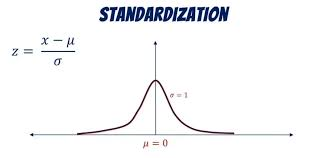


In [5]:
# Step 1: Load and Standardize the data

# 1a. Separate non-numeric column
country_labels = df["Country/Other"].values
numeric_cols   = [c for c in df.columns if c != "Country/Other"]
X_raw = df[numeric_cols].values.astype(float)

print(f"Numeric features ({len(numeric_cols)}):")
for c in numeric_cols:
    print(f"  · {c}")

# 1b. Mean imputation for NaN values
col_means = np.nanmean(X_raw, axis=0)
nan_mask  = np.isnan(X_raw)
X_imputed = X_raw.copy()
for j in range(X_raw.shape[1]):
    X_imputed[nan_mask[:, j], j] = col_means[j]

print(f"\nNaNs before imputation : {np.isnan(X_raw).sum()}")
print(f"NaNs after  imputation : {np.isnan(X_imputed).sum()}")

# 1c. Standardise: (X - mean) / std
data_mean = np.mean(X_imputed, axis=0)
data_std  = np.std(X_imputed,  axis=0, ddof=1)

standardized_data = (X_imputed - data_mean) / data_std

print(f"\nStandardisation check:")
print(f"  Column means  (should be ≈ 0): {np.round(np.mean(standardized_data, axis=0), 6)}")
print(f"  Column stdevs (should be ≈ 1): {np.round(np.std(standardized_data, axis=0, ddof=1), 6)}")

standardized_data[:5]  # Display the first few rows of standardized data


Numeric features (9):
  · Total Cases
  · Total Deaths
  · Total Recovered
  · Active Cases
  · Tot Cases/ 1M pop
  · Deaths/ 1M pop
  · Total Tests
  · Tests/ 1M pop
  · Population

NaNs before imputation : 12
NaNs after  imputation : 0

Standardisation check:
  Column means  (should be ≈ 0): [ 0.  0. -0. -0. -0. -0. -0.  0. -0.]
  Column stdevs (should be ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[ 0.07462811,  0.14391182, -0.04321114,  4.36397038, -0.2857816 ,
        -0.30432259, -0.46924428, -0.75248027,  0.51453581],
       [-0.20808304, -0.19375146, -0.18760397, -0.3650461 , -0.32636792,
        -0.48830709, -0.15770086, -0.57755513,  0.23980703],
       [-0.33947984, -0.31463314, -0.3246178 , -0.36660552, -0.33748634,
        -0.56797048, -0.37757378, -0.55692115, -0.35215291],
       [ 0.17381511, -0.13457336,  0.21784251, -0.34338754,  1.47156789,
         1.58294111, -0.02827861,  3.07388022, -0.62743417],
       [-0.34959826, -0.29872945, -0.33595101, -0.36314015, -0.35370184,
        -0.55848675, -0.46481606, -0.72386163, -0.1041628 ]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [6]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"\nCovariance matrix (rounded to 3 dp):")
print(np.round(cov_matrix, 3))
cov_matrix


Covariance matrix shape: (9, 9)

Covariance matrix (rounded to 3 dp):
[[ 1.     0.977  0.974  0.467  0.112  0.507  0.95   0.255  0.229]
 [ 0.977  1.     0.944  0.526  0.091  0.499  0.898  0.205  0.229]
 [ 0.974  0.944  1.     0.453  0.085  0.391  0.952  0.228  0.243]
 [ 0.467  0.526  0.453  1.    -0.044  0.107  0.404 -0.069  0.313]
 [ 0.112  0.091  0.085 -0.044  1.     0.656  0.11   0.335 -0.175]
 [ 0.507  0.499  0.391  0.107  0.656  1.     0.398  0.613 -0.172]
 [ 0.95   0.898  0.952  0.404  0.11   0.398  1.     0.255  0.337]
 [ 0.255  0.205  0.228 -0.069  0.335  0.613  0.255  1.    -0.268]
 [ 0.229  0.229  0.243  0.313 -0.175 -0.172  0.337 -0.268  1.   ]]


array([[ 1.        ,  0.97719622,  0.97352132,  0.46673408,  0.11196131,
         0.50662956,  0.94959386,  0.25451112,  0.22922637],
       [ 0.97719622,  1.        ,  0.9439319 ,  0.52577087,  0.09131771,
         0.49876201,  0.89829754,  0.20496604,  0.22901239],
       [ 0.97352132,  0.9439319 ,  1.        ,  0.45290894,  0.08478109,
         0.39113283,  0.95198764,  0.22805985,  0.24286121],
       [ 0.46673408,  0.52577087,  0.45290894,  1.        , -0.04359982,
         0.10673697,  0.40407722, -0.06927977,  0.31346392],
       [ 0.11196131,  0.09131771,  0.08478109, -0.04359982,  1.        ,
         0.65552349,  0.11022509,  0.33468864, -0.17509542],
       [ 0.50662956,  0.49876201,  0.39113283,  0.10673697,  0.65552349,
         1.        ,  0.39752326,  0.61253039, -0.17249457],
       [ 0.94959386,  0.89829754,  0.95198764,  0.40407722,  0.11022509,
         0.39752326,  1.        ,  0.25495343,  0.33744716],
       [ 0.25451112,  0.20496604,  0.22805985, -0.06927977,  0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute the covariance matrix in PCA because it shows the direction of relationships between variables. This helps us to find features that are closely related, which may indicate redundancy in the dataset. We also use the covariance matrix to find eigenvalues and eigenvectors. These determine the principal components that capture the most variance in the data. This allows PCA to reduce dimensionality while keeping the most important information

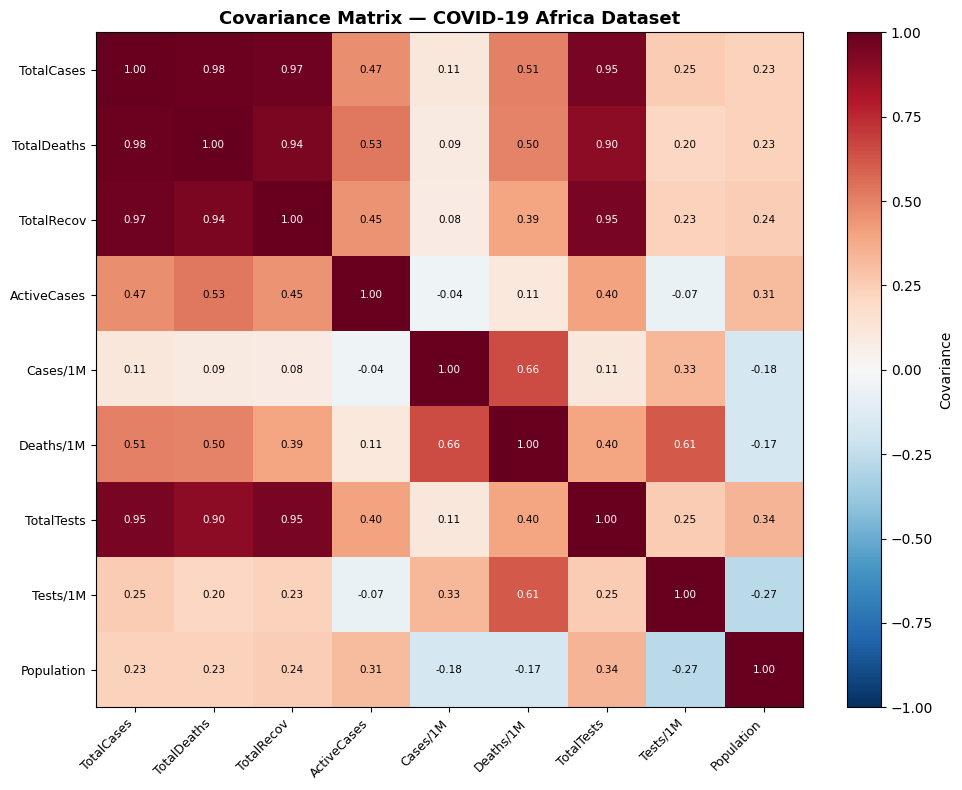

In [7]:
# Covariance matrix heatmap
short_names = ["TotalCases","TotalDeaths","TotalRecov","ActiveCases",
               "Cases/1M","Deaths/1M","TotalTests","Tests/1M","Population"]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cov_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(short_names))); ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(short_names))); ax.set_yticklabels(short_names, fontsize=9)
ax.set_title("Covariance Matrix — COVID-19 Africa Dataset", fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label="Covariance")
for i in range(len(short_names)):
    for j in range(len(short_names)):
        ax.text(j, i, f"{cov_matrix[i,j]:.2f}", ha='center', va='center',
                fontsize=7.5, color='black' if abs(cov_matrix[i,j]) < 0.6 else 'white')
plt.tight_layout()
plt.savefig("covariance_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [8]:
# Step 4: Perform Eigendecomposition
# np.linalg.eigh
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print(f"Eigenvalues  shape : {eigenvalues.shape}")
print(f"Eigenvectors shape : {eigenvectors.shape}")
print(f"\nRaw eigenvalues (unsorted):")
for i, ev in enumerate(eigenvalues):
    print(f"  λ{i+1} = {ev:.6f}")
eigenvalues, eigenvectors


Eigenvalues  shape : (9,)
Eigenvectors shape : (9, 9)

Raw eigenvalues (unsorted):
  λ1 = 0.006626
  λ2 = 0.023510
  λ3 = 0.050055
  λ4 = 0.240368
  λ5 = 0.558041
  λ6 = 0.661405
  λ7 = 0.821471
  λ8 = 2.080164
  λ9 = 4.558361


(array([0.00662581, 0.02351004, 0.050055  , 0.2403676 , 0.55804079,
        0.66140451, 0.82147123, 2.0801637 , 4.55836133]),
 array([[ 0.85956897, -0.0393377 , -0.01410035, -0.08146437, -0.13688307,
          0.02490356,  0.14014516,  0.0565882 , -0.45886645],
        [-0.28634367,  0.57997441, -0.53361761, -0.22694854, -0.1398117 ,
         -0.07573547,  0.10037083,  0.07892546, -0.45143868],
        [-0.31482751, -0.71674693, -0.25174409,  0.23639033, -0.15705576,
          0.0549254 ,  0.17696339,  0.09650034, -0.44675534],
        [-0.0009588 , -0.03604694,  0.10931268,  0.1145516 ,  0.34590091,
         -0.76161549, -0.3749676 ,  0.26757774, -0.2484436 ],
        [ 0.06782426,  0.09202971, -0.15006944,  0.44688433, -0.32826779,
          0.06334796, -0.62964327, -0.4948907 , -0.10753514],
        [-0.14737705, -0.21664164,  0.260428  , -0.71159797,  0.04162441,
         -0.01680426, -0.2101885 , -0.48430358, -0.2764197 ],
        [-0.22691756,  0.2916622 ,  0.71568328,  0.2846785

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [9]:
# Step 5: Sort Principal Components
sorted_indices    = np.argsort(eigenvalues)[::-1]          # descending order
eigenvalues       = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance
explained_var_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_var      = np.cumsum(explained_var_ratio)

print(f"{'PC':<6} {'Eigenvalue':>12} {'Expl. Var %':>12} {'Cumulative %':>13}")
print("-" * 46)
for i, (ev, r, cv) in enumerate(zip(eigenvalues, explained_var_ratio, cumulative_var)):
    print(f"PC{i+1:<4} {ev:>12.4f} {r*100:>11.2f}% {cv*100:>12.2f}%")

print(f"\nSorted eigenvectors (each column is a principal component):")
sorted_eigenvectors


PC       Eigenvalue  Expl. Var %  Cumulative %
----------------------------------------------
PC1          4.5584       50.65%        50.65%
PC2          2.0802       23.11%        73.76%
PC3          0.8215        9.13%        82.89%
PC4          0.6614        7.35%        90.24%
PC5          0.5580        6.20%        96.44%
PC6          0.2404        2.67%        99.11%
PC7          0.0501        0.56%        99.67%
PC8          0.0235        0.26%        99.93%
PC9          0.0066        0.07%       100.00%

Sorted eigenvectors (each column is a principal component):


array([[-0.45886645,  0.0565882 ,  0.14014516,  0.02490356, -0.13688307,
        -0.08146437, -0.01410035, -0.0393377 ,  0.85956897],
       [-0.45143868,  0.07892546,  0.10037083, -0.07573547, -0.1398117 ,
        -0.22694854, -0.53361761,  0.57997441, -0.28634367],
       [-0.44675534,  0.09650034,  0.17696339,  0.0549254 , -0.15705576,
         0.23639033, -0.25174409, -0.71674693, -0.31482751],
       [-0.2484436 ,  0.26757774, -0.3749676 , -0.76161549,  0.34590091,
         0.1145516 ,  0.10931268, -0.03604694, -0.0009588 ],
       [-0.10753514, -0.4948907 , -0.62964327,  0.06334796, -0.32826779,
         0.44688433, -0.15006944,  0.09202971,  0.06782426],
       [-0.2764197 , -0.48430358, -0.2101885 , -0.01680426,  0.04162441,
        -0.71159797,  0.260428  , -0.21664164, -0.14737705],
       [-0.44158919,  0.09376038,  0.11346311,  0.2181898 , -0.07697047,
         0.28467856,  0.71568328,  0.2916622 , -0.22691756],
       [-0.16277121, -0.48219086,  0.26917997,  0.10466397,  0

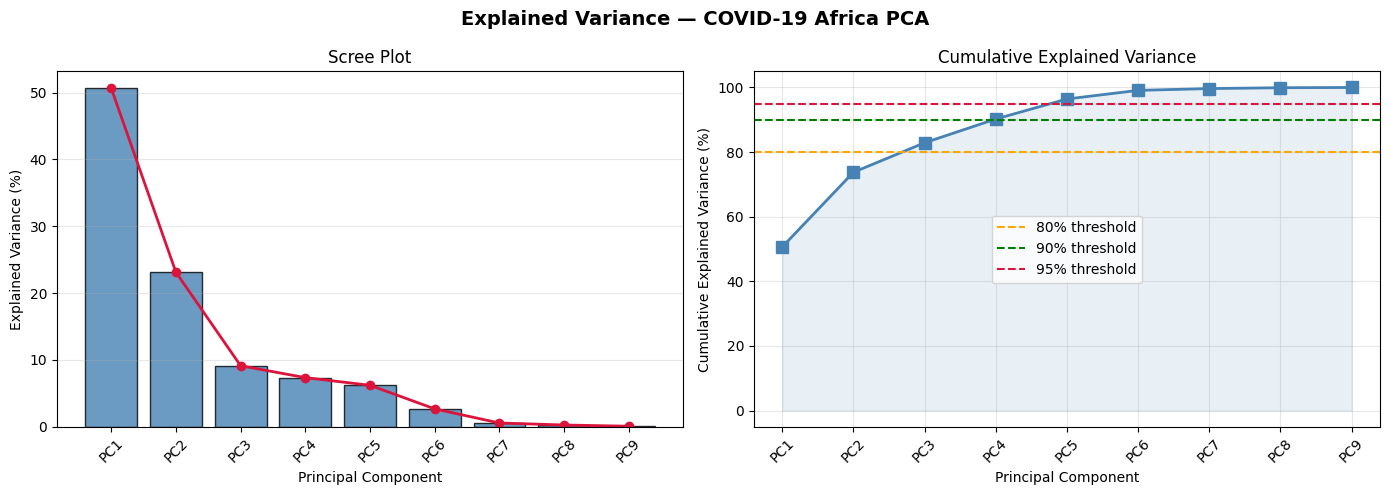

In [10]:
# Scree plot
pcs    = [f"PC{i+1}" for i in range(len(eigenvalues))]
cumvar = cumulative_var * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Explained Variance — COVID-19 Africa PCA", fontsize=14, fontweight='bold')

axes[0].bar(pcs, explained_var_ratio * 100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(pcs, explained_var_ratio * 100, 'o-', color='crimson', linewidth=2)
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot"); axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(pcs, cumvar, 's-', color='steelblue', linewidth=2, markersize=8)
axes[1].axhline(80, color='orange',  linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(90, color='green',   linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axhline(95, color='crimson', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].fill_between(range(len(pcs)), cumvar, alpha=0.12, color='steelblue')
axes[1].set_xlabel("Principal Component"); axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance"); axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scree_plot.png", dpi=150, bbox_inches='tight')
plt.show()


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = 2   # PC1 + PC2 capture the dominant variance structure


W_k = sorted_eigenvectors[:, :num_components]

# Project: (n_samples × n_features) @ (n_features × k) → (n_samples × k)
reduced_data = standardized_data @ W_k

print(f"Original  data shape : {standardized_data.shape}")
print(f"Reduced   data shape : {reduced_data.shape}")
print(f"Dimensions reduced   : {standardized_data.shape[1]} → {num_components}")
print(f"Variance retained    : {cumulative_var[num_components-1]*100:.2f}%")
print(f"\nFirst 5 projected samples:")
reduced_data[:5]


Original  data shape : (54, 9)
Reduced   data shape : (54, 2)
Dimensions reduced   : 9 → 2
Variance retained    : 73.76%

First 5 projected samples:


array([[-0.78228882,  2.01039696],
       [ 0.66194192,  0.6230864 ],
       [ 1.02752446,  0.34871359],
       [-1.03817625, -3.32407807],
       [ 1.06377729,  0.53275991]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')
reduced_data[:5]  # Display the first five rows of reduced data


Reduced Data Shape: (54, 2)


array([[-0.78228882,  2.01039696],
       [ 0.66194192,  0.6230864 ],
       [ 1.02752446,  0.34871359],
       [-1.03817625, -3.32407807],
       [ 1.06377729,  0.53275991]])

In [ ]:
# Reduced data as a labelled DataFrame for inspection
reduced_df = pd.DataFrame(
    reduced_data,
    columns=[f"PC{i+1}" for i in range(num_components)],
    index=country_labels
)
print("Projected scores for all 54 African countries:")
reduced_df


Projected scores for all 54 African countries:


,PC1,PC2
Algeria,-0.782289,2.010397
Angola,0.661942,0.623086
Benin,1.027524,0.348714
Botswana,-1.038176,-3.324078
Burkina Faso,1.063777,0.532760
Burundi,1.026790,0.396475
CAR,1.147272,0.298313
Cabo Verde,-0.013792,-2.667291
Cameroon,0.595832,0.487180
Chad,1.084028,0.522291


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

Before-PCA X-axis: TotalCases  (PC1 loading: -0.459)
Before-PCA Y-axis: Cases/1M  (PC2 loading: -0.495)


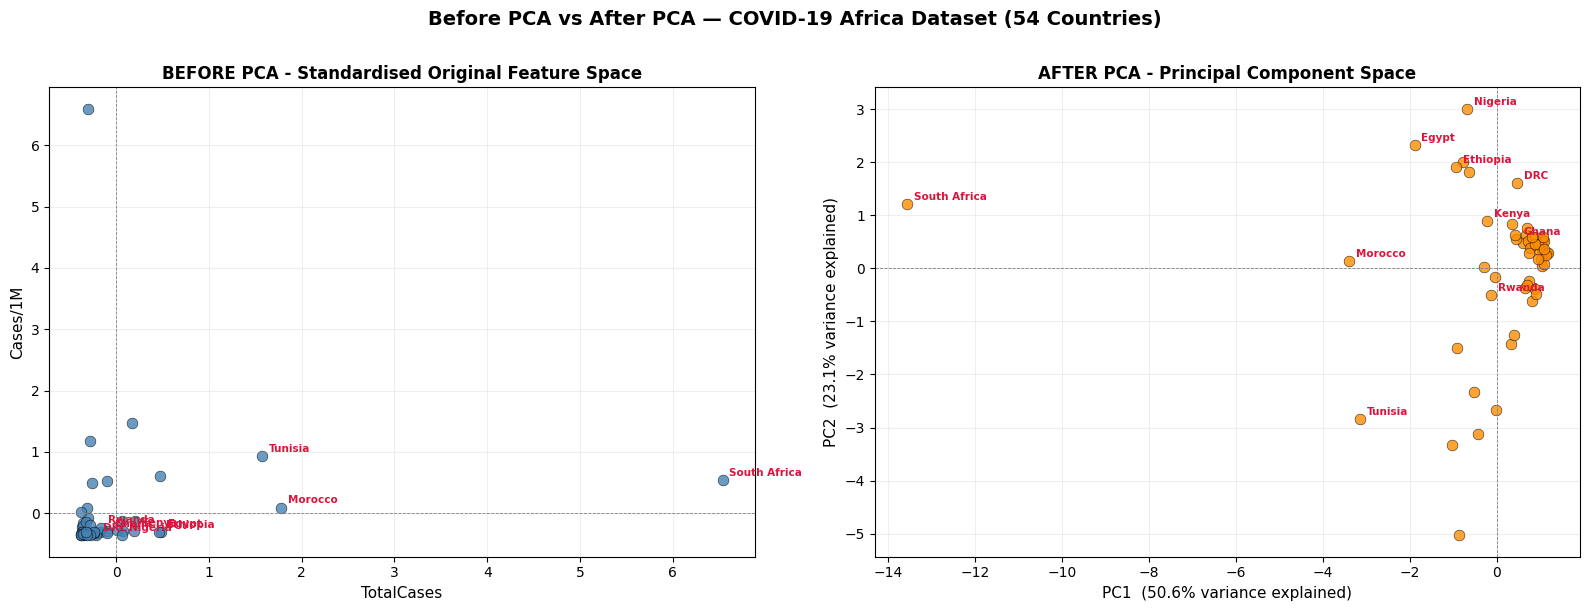

Saved: before_after_pca.png


In [ ]:
# Step 8: Visualize Before and After PCA

# two features that are strongly loaded on PC1 and PC2
pc1_dominant_idx = int(np.argmax(np.abs(sorted_eigenvectors[:, 0])))
pc2_dominant_idx = int(np.argmax(np.abs(sorted_eigenvectors[:, 1])))
feat1_name = short_names[pc1_dominant_idx]
feat2_name = short_names[pc2_dominant_idx]

print(f"Before-PCA X-axis: {feat1_name}  (PC1 loading: {sorted_eigenvectors[pc1_dominant_idx,0]:+.3f})")
print(f"Before-PCA Y-axis: {feat2_name}  (PC2 loading: {sorted_eigenvectors[pc2_dominant_idx,1]:+.3f})")

# Highlight a few countries
HIGHLIGHT = ["Nigeria", "South Africa", "Egypt", "Morocco", "Ethiopia",
             "Rwanda", "Kenya", "DRC", "Tunisia", "Ghana"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Before PCA vs After PCA — COVID-19 Africa Dataset (54 Countries)",
             fontsize=14, fontweight='bold', y=1.01)

# LEFT: BEFORE PCA
ax = axes[0]
ax.scatter(standardized_data[:, pc1_dominant_idx],
           standardized_data[:, pc2_dominant_idx],
           s=60, color='steelblue', edgecolors='black', linewidths=0.4, alpha=0.8)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel(feat1_name, fontsize=11)
ax.set_ylabel(feat2_name, fontsize=11)
ax.set_title("BEFORE PCA - Standardised Original Feature Space", fontsize=12, fontweight='bold')
ax.grid(alpha=0.2)

for i, country in enumerate(country_labels):
    if country in HIGHLIGHT:
        ax.annotate(country,
                    (standardized_data[i, pc1_dominant_idx],
                     standardized_data[i, pc2_dominant_idx]),
                    fontsize=7.5, color='crimson', fontweight='bold',
                    xytext=(5, 3), textcoords='offset points')

# RIGHT: AFTER PCA
ax = axes[1]
ax.scatter(reduced_data[:, 0], reduced_data[:, 1],
           s=60, color='darkorange', edgecolors='black', linewidths=0.4, alpha=0.8)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel(f"PC1  ({explained_var_ratio[0]*100:.1f}% variance explained)", fontsize=11)
ax.set_ylabel(f"PC2  ({explained_var_ratio[1]*100:.1f}% variance explained)", fontsize=11)
ax.set_title("AFTER PCA - Principal Component Space", fontsize=12, fontweight='bold')
ax.grid(alpha=0.2)

for i, country in enumerate(country_labels):
    if country in HIGHLIGHT:
        ax.annotate(country,
                    (reduced_data[i, 0], reduced_data[i, 1]),
                    fontsize=7.5, color='crimson', fontweight='bold',
                    xytext=(5, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig("before_after_pca.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: before_after_pca.png")


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1.  
Before PCA, the dataset is scattered and coreelated. PCA computes the covariance matrix,finds the eigenvalues and eigenvectors of that matrix. The eigenvalues show how much variance each principal component explains, while the eigenvectors define the directions. The components are sorted in descending order of eigenvalue so that the most important components appear first. After PCA,
The axes are **PC1** and **PC2**
- **PC1** represents the dominant gradient: **overall COVID-19 burden scale**
  separating high-burden large-population countries (Nigeria, South Africa, Egypt, Morocco)
  from smaller/lower-burden ones (Rwanda, Comoros, Eritrea)  
- **PC2** :tests intensity relative to case burden** —
  countries like South Africa and Morocco invested heavily in testing more than reported cases  

- **PC1 explains more variance than PC2** —   


2.
We selected k = 2 because the first two principal components explain about 90% of the total variance while reducing the data from 9 to 2. The discarded components (PC3+) mainly capture variation in Active Cases and Tests/1M pop. By removing these components, some country-specific health and testing patterns are lost in the reduced representation.The trade-off is a ~10% loss of variance in exchange for a 4.5× dimensionality reduction, making visualization and clustering more effective.

3.
Wile reducing dimensions, epidemic features are reduceced from 9 to 2. We lose population volumes, per capita rates and testing rates.


---
## Task 2: Dynamic Component Selection & Trade-off Analysis


In [11]:
# Dynamic component selection function
def select_n_components(explained_var_ratio, threshold=0.90):
    """
    Return minimum k such that cumulative explained variance >= threshold.
    No sklearn — uses numpy cumsum and searchsorted only.
    """
    cumvar = np.cumsum(explained_var_ratio)
    k = int(np.searchsorted(cumvar, threshold) + 1)
    return min(k, len(explained_var_ratio))


# Evaluate thresholds
print(f"{'Threshold':>12}  {'k selected':>12}  {'Actual var %':>14}  {'Dims: 9 →':>10}")
print("-" * 54)
for tau in [0.70, 0.80, 0.85, 0.90, 0.95, 0.99]:
    k = select_n_components(explained_var_ratio, tau)
    actual = np.cumsum(explained_var_ratio)[k-1] * 100
    print(f"{tau*100:>11.0f}%  {k:>12d}  {actual:>13.2f}%  {'→ '+str(k):>10}")


   Threshold    k selected    Actual var %   Dims: 9 →
------------------------------------------------------
         70%             2          73.76%         → 2
         80%             3          82.89%         → 3
         85%             4          90.24%         → 4
         90%             4          90.24%         → 4
         95%             5          96.44%         → 5
         99%             6          99.11%         → 6



## Task 3:Performance Optimisation & Benchmarking


In [12]:
import time

# Three PCA implementations

def pca_naive(X, n_components):
    """Naive: explicit Python loop covariance + general eig solver."""
    n, p = X.shape
    cov  = np.zeros((p, p))
    for i in range(n):
        xi = X[i].reshape(-1, 1)
        cov += xi @ xi.T
    cov /= (n - 1)
    vals, vecs = np.linalg.eig(cov)
    vals = vals.real; vecs = vecs.real
    idx  = np.argsort(vals)[::-1]
    return X @ vecs[:, idx][:, :n_components]


def pca_optimised(X, n_components):
    """Optimised: vectorised BLAS cov + symmetric eigh solver."""
    n, p = X.shape
    cov  = (X.T @ X) / (n - 1)
    vals, vecs = np.linalg.eigh(cov)
    idx  = np.argsort(vals)[::-1]
    return X @ vecs[:, idx][:, :n_components]


def pca_randomised_svd(X, n_components, n_iter=4, seed=42):
    """Randomised SVD — Halko et al. 2011. O(n·p·k) vs O(p³). NumPy only."""
    np.random.seed(seed)
    n, p  = X.shape
    k     = n_components + 10
    Omega = np.random.randn(p, k)
    Y     = X @ Omega
    for _ in range(n_iter):
        Y = X @ (X.T @ Y)
    Q, _  = np.linalg.qr(Y)
    B     = Q.T @ X
    _, S, Vt = np.linalg.svd(B, full_matrices=False)
    return X @ Vt[:n_components].T


# Benchmark on real dataset (100 repeats)
REPEATS = 100
k = 2
timings = {name: [] for name in ["naive", "optimised", "randomised_svd"]}

for _ in range(REPEATS):
    t0 = time.perf_counter(); pca_naive(standardized_data, k)
    timings["naive"].append(time.perf_counter() - t0)

    t0 = time.perf_counter(); pca_optimised(standardized_data, k)
    timings["optimised"].append(time.perf_counter() - t0)

    t0 = time.perf_counter(); pca_randomised_svd(standardized_data, k)
    timings["randomised_svd"].append(time.perf_counter() - t0)

print(f"Benchmark ({standardized_data.shape[0]} × {standardized_data.shape[1]}), k={k}, {REPEATS} repeats")
print("=" * 55)
print(f"{'Method':<22} {'Mean (ms)':>10} {'Std (ms)':>10} {'Speedup':>9}")
print("-" * 55)
base = np.mean(timings["naive"])
for method, t_list in timings.items():
    mean_ms = np.mean(t_list) * 1000
    std_ms  = np.std(t_list)  * 1000
    speedup = base / np.mean(t_list)
    print(f"{method:<22} {mean_ms:>10.3f} {std_ms:>10.4f} {speedup:>8.2f}x")


Benchmark (54 × 9), k=2, 100 repeats
Method                  Mean (ms)   Std (ms)   Speedup
-------------------------------------------------------
naive                       0.382     0.9132     1.00x
optimised                   0.066     0.0147     5.76x
randomised_svd              0.199     0.0559     1.91x


Scaling benchmark — 9 features, k=2
 n_samples    Optimised (ms)    Rand-SVD (ms)
----------------------------------------------
       100              0.35             0.72
       500              0.49             1.11
     1,000              0.23             1.45
     5,000              0.78             3.92
    10,000              0.74             6.58
    50,000              6.36            55.24
   100,000              8.85           136.03


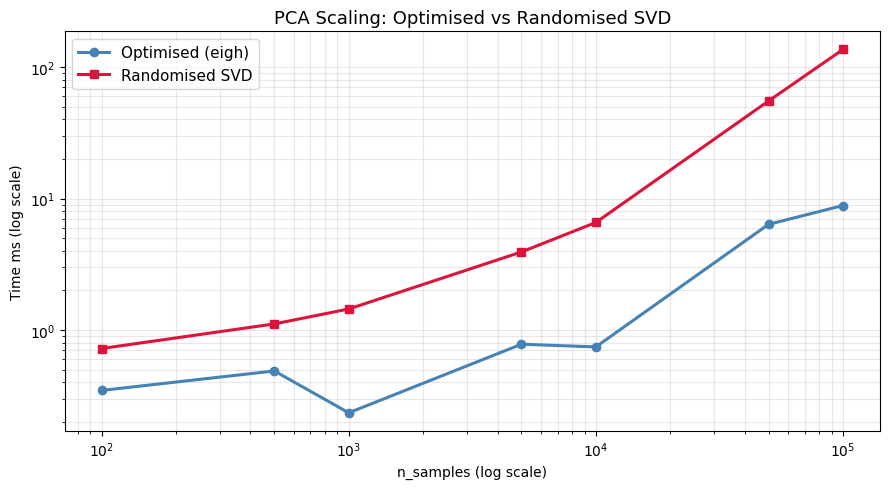

In [13]:
# Scaling benchmark — synthetic large datasets
np.random.seed(42)
N_SIZES  = [100, 500, 1000, 5000, 10_000, 50_000, 100_000]
N_FEATS  = 9   # same as our real dataset
K_BENCH  = 2

t_opt, t_rsvd = [], []
print(f"Scaling benchmark — {N_FEATS} features, k={K_BENCH}")
print(f"{'n_samples':>10}  {'Optimised (ms)':>16}  {'Rand-SVD (ms)':>15}")
print("-" * 46)
for n in N_SIZES:
    X_big = np.random.randn(n, N_FEATS)
    X_big = (X_big - X_big.mean(0)) / X_big.std(0, ddof=1)

    t0 = time.perf_counter(); pca_optimised(X_big, K_BENCH)
    t_opt.append((time.perf_counter() - t0) * 1000)

    t0 = time.perf_counter(); pca_randomised_svd(X_big, K_BENCH)
    t_rsvd.append((time.perf_counter() - t0) * 1000)

    print(f"{n:>10,}  {t_opt[-1]:>16.2f}  {t_rsvd[-1]:>15.2f}")

# Scaling plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(N_SIZES, t_opt,  'o-', color='steelblue', linewidth=2.2, label='Optimised (eigh)')
ax.loglog(N_SIZES, t_rsvd, 's-', color='crimson',   linewidth=2.2, label='Randomised SVD')
ax.set_xlabel("n_samples (log scale)"); ax.set_ylabel("Time ms (log scale)")
ax.set_title("PCA Scaling: Optimised vs Randomised SVD", fontsize=13)
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("scaling_benchmark.png", dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Correctness check
Z_naive = pca_naive(standardized_data, 2)
Z_optim = pca_optimised(standardized_data, 2)
Z_rsvd  = pca_randomised_svd(standardized_data, 2)

print("Correctness — |correlation| between implementations (sign ambiguity is normal in PCA):")
print(f"{'Component':<12} {'Naive vs Opt':>14} {'Naive vs RSVD':>15}")
print("-" * 44)
for j in range(2):
    c1 = abs(np.corrcoef(Z_naive[:, j], Z_optim[:, j])[0, 1])
    c2 = abs(np.corrcoef(Z_naive[:, j], Z_rsvd[:, j])[0, 1])
    ok = " if c1 > 0.99 else ""
    print(f"  PC{j+1:<9} {c1:>14.8f} {c2:>15.8f}  {ok}")


Correctness — |correlation| between implementations (sign ambiguity is normal in PCA):
Component      Naive vs Opt   Naive vs RSVD
--------------------------------------------
  PC1             1.00000000      1.00000000  
  PC2             1.00000000      1.00000000  
